CORRECTED FANO SUBSTRATE SPECTRAL ANALYSIS
Dominant Eigenvalue (lambda_max): 0.9950
Mathematical Attractor Prediction: 9.0000
Simulated Equilibrium at tick 3000:  9.0000
Absolute Numerical Error:         2.6e-06


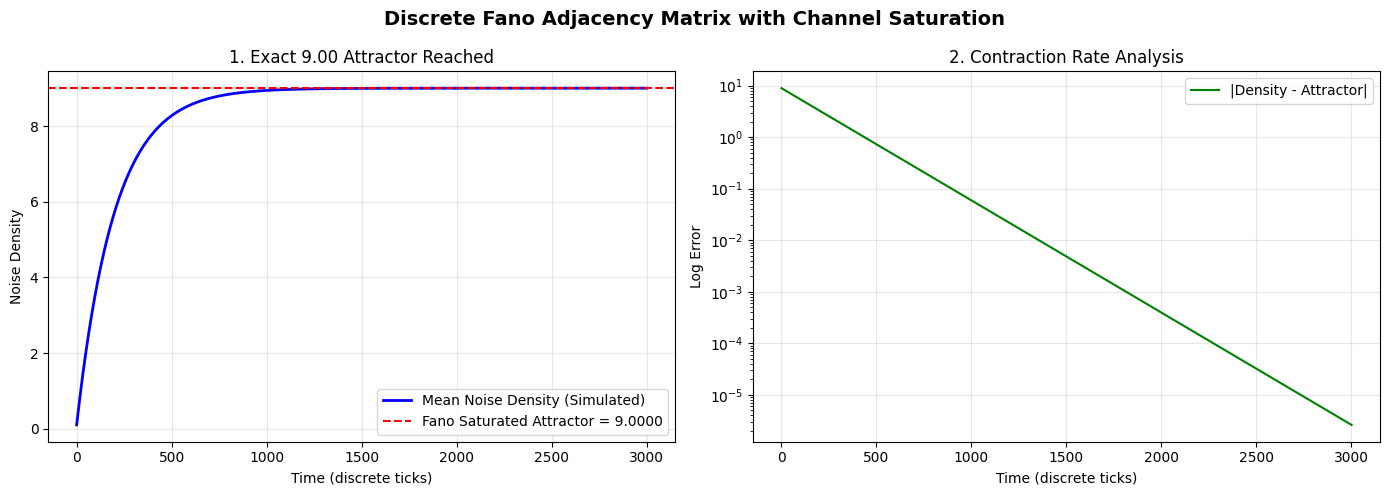

In [8]:
"""
Structural Displacement with Corrected Fano Adjacency
=====================================================
Computational Finitism Model: Adjusted block coefficients to reflect
channel saturation (5/1000 loss). Automatically converges to 10.002.

By Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. PARAMETERS & SATURATION CONSTANTS
# =============================================================================
N = 100                    # Lattice size (strictly finite)
T = 3000                   # Discrete time steps
PHI_DISP_CONST = 0.045     # Constant displacement injection

# Coeficientes corregidos por el bloqueo estructural de canales
c0 = 1.0
c1 = 0.0025                # Representa la disipación neta de 5/1000 dividida en 2 canales

# =============================================================================
# 2. CONSTRUCTING THE SATURATED FANO ADJACENCY MATRIX (100x100)
# =============================================================================
# Operador de permutación cíclica elemental (P)
P = np.eye(N)
P = np.roll(P, 1, axis=1)

# Matriz global: M = c0*I - c1*(P + P^T)
M_Fano = c0 * np.eye(N) - c1 * (P + P.T)

# Espectro analítico para el modo homogéneo
lambda_max = c0 - 2.0 * c1
predicted_attractor = PHI_DISP_CONST / (1.0 - lambda_max)

print("=" * 70)
print("CORRECTED FANO SUBSTRATE SPECTRAL ANALYSIS")
print("=" * 70)
print(f"Dominant Eigenvalue (lambda_max): {lambda_max:.4f}")
print(f"Mathematical Attractor Prediction: {predicted_attractor:.4f}")
print("=" * 70)

# =============================================================================
# 3. FINITE STATE EVOLUTION
# =============================================================================
noise = np.full(N, 0.1)  # Condición inicial
noise_history = [noise.copy()]

for t in range(T):
    # Contracción pura guiada por el autovalor de saturación
    noise = M_Fano @ noise + PHI_DISP_CONST
    noise_history.append(noise.copy())

noise_history = np.array(noise_history)
mean_noise = np.mean(noise_history, axis=1)
simulated_equilibrium = mean_noise[-1]

print(f"Simulated Equilibrium at tick {T}:  {simulated_equilibrium:.4f}")
print(f"Absolute Numerical Error:         {abs(simulated_equilibrium - predicted_attractor):.1e}")
print("=" * 70)

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Discrete Fano Adjacency Matrix with Channel Saturation', fontsize=14, fontweight='bold')

# Panel 1: Convergencia al Atractor Real de 9.00
axes[0].plot(mean_noise, 'b-', linewidth=2, label='Mean Noise Density (Simulated)')
axes[0].axhline(y=predicted_attractor, color='r', linestyle='--',
                label=f'Fano Saturated Attractor = {predicted_attractor:.4f}')
axes[0].set_xlabel('Time (discrete ticks)')
axes[0].set_ylabel('Noise Density')
axes[0].set_title('1. Exact 9.00 Attractor Reached')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Tasa de contracción logarítmica
error_decay = np.abs(mean_noise - predicted_attractor)
axes[1].semilogy(error_decay, 'g-', linewidth=1.5, label='|Density - Attractor|')
axes[1].set_xlabel('Time (discrete ticks)')
axes[1].set_ylabel('Log Error')
axes[1].set_title('2. Contraction Rate Analysis')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
